In [1]:
import pickle
from siamese_torch import ImagePairDataset
import matplotlib.pyplot as plt
from glob import glob
from datasets import load_dataset


In [3]:
hf_dataset = load_dataset("agucci/mri-sym2")

In [4]:
# for n, i in enumerate(hf_dataset['train']):
#     if i['session'] == 158900: 
#         print(n)
#         print(i)

[{'x': 30.53, 'y': 137.73} {'x': 246.75, 'y': 147.18}]


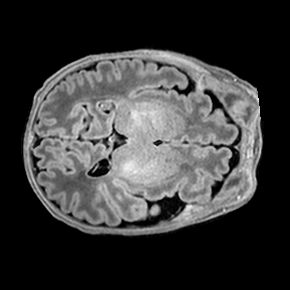

In [5]:
print((hf_dataset['train']['line'][0]))
line0 = (hf_dataset['train']['line'][0])
# hf_dataset['train']['image'][0]
hf_dataset['train']['image'][0]

In [6]:
line_coords = eval(line0.replace('} {', '}, {'))
line_coords


[{'x': 30.53, 'y': 137.73}, {'x': 246.75, 'y': 147.18}]

In [7]:
with open('../siamese/data/pairs_white_90.pkl', 'rb') as f:
        data = pickle.load(f)

# arrays of shape (n, 2, 256, 256)
pairs_train_mri_noise = data['pairs_train_mri']
pairs_test_mri_noise  = data['pairs_test_mri']
# arrays of shape (n, )
labels_train_mri_noise = data['labels_train_mri']
labels_test_mri_noise = data['labels_test_mri']

In [8]:
train_dataset = ImagePairDataset(pairs_train_mri_noise, labels_train_mri_noise)
test_dataset = ImagePairDataset(pairs_test_mri_noise, labels_test_mri_noise)

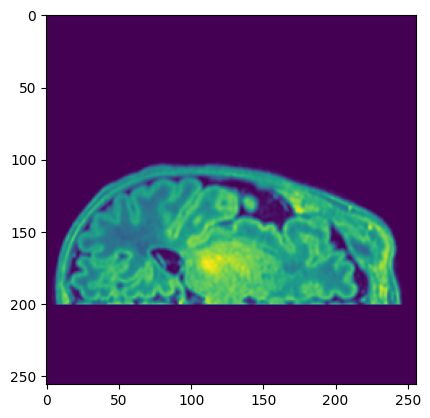

In [9]:
plt.imshow(train_dataset[0][0].squeeze())

In [10]:
pairs_train_mri_noise[:2].shape

(2, 2, 256, 256)

In [11]:
[i for i in range(5)][0:5:3]

[0, 3]

In [12]:
imgs = [train_dataset[i][0].squeeze() for i in range(8, 16, 1)]
imgs = pairs_train_mri_noise[8:24:2]

labels_train_mri_noise[:8]

array([0., 1., 0., 1., 0., 1., 0., 1.], dtype=float32)

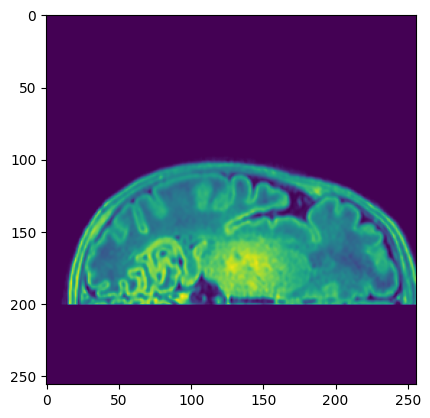

In [13]:
plt.imshow(imgs[0][0])

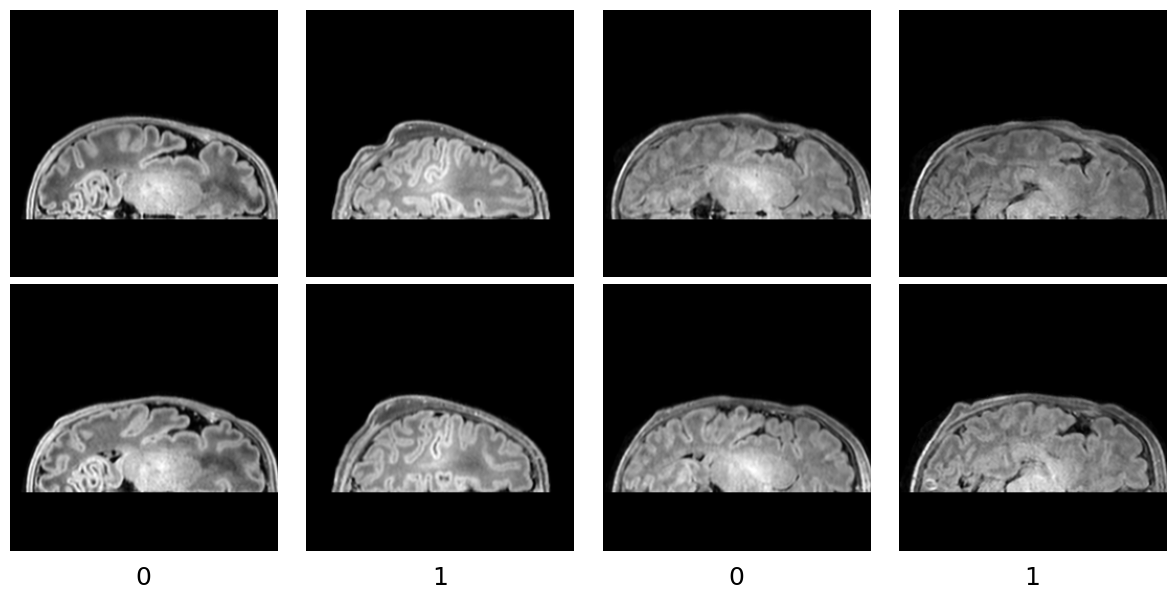

In [14]:
_, axs = plt.subplots(2, 4, figsize=(12, 6))
axs = axs.flatten()
for i, (img, ax) in enumerate(zip(imgs, axs[:4])):
    ax.imshow(img[0], cmap='gray')
    ax.axis('off')
for i, (img, ax) in enumerate(zip(imgs, axs[4:])):
    ax.imshow(img[1], cmap='gray')
    ax.axis('off')
    if i%2==0:
        ax.annotate("0", xy=(0.5, -0.1), xycoords='axes fraction',
                        va='center', ha='center', fontsize=18)
    else:
        ax.annotate("1", xy=(0.5, -0.1), xycoords='axes fraction',
                        va='center', ha='center', fontsize=18)

plt.tight_layout()
plt.show()

In [15]:
def plot_data(pickle_file):

    with open(pickle_file, 'rb') as f:
        data = pickle.load(f)

    # GRAY : arrays of shape (n, 2, 256, 256)
    # RGB : arrays of shape (n, 2, 256, 256, 3)
    training_pairs = data['pairs_train_mri']
    testing_pairs  = data['pairs_test_mri']
    # arrays of shape (n, )
    training_labels = data['labels_train_mri']
    testing_labels = data['labels_test_mri']

    imgs_train = training_pairs[:16]
    imgs_test = testing_pairs[:16]

    #plot 1
    _, axs = plt.subplots(4, 4, figsize=(11, 6))
    axs = axs.flatten()
    for i, (img, ax) in enumerate(zip(imgs_train, axs[:8])):
        ax.imshow(img[0], cmap='gray')
        ax.axis('off')
    for i, (img, ax) in enumerate(zip(imgs_train, axs[8:])):
        ax.imshow(img[1], cmap='gray')
        ax.axis('off')
        if i%2==0:
            ax.annotate("0", xy=(0.5, -0.1), xycoords='axes fraction',
                            va='center', ha='center', fontsize=18)
        else:
            ax.annotate("1", xy=(0.5, -0.1), xycoords='axes fraction',
                            va='center', ha='center', fontsize=18)
    axs[0].annotate("Training", xy=(-0.2, -0.2), xycoords='axes fraction',
                        va='center', ha='right', rotation=90, fontsize=16)
    # plt.tight_layout()
    plt.show()

    #plot 2
    _, axs = plt.subplots(2, 4, figsize=(11, 6))
    axs = axs.flatten()
    for i, (img, ax) in enumerate(zip(imgs_test, axs[:4])):
        ax.imshow(img[0], cmap='gray')
        ax.axis('off')
    for i, (img, ax) in enumerate(zip(imgs_test, axs[4:])):
        ax.imshow(img[1], cmap='gray')
        ax.axis('off')
        if i%2==0:
            ax.annotate("0", xy=(0.5, -0.1), xycoords='axes fraction',
                            va='center', ha='center', fontsize=18)
        else:
            ax.annotate("1", xy=(0.5, -0.1), xycoords='axes fraction',
                            va='center', ha='center', fontsize=18)
    axs[0].annotate("Testing", xy=(-0.2, -0.2), xycoords='axes fraction',
                        va='center', ha='right', rotation=90, fontsize=16)
    # plt.tight_layout()
    plt.show()

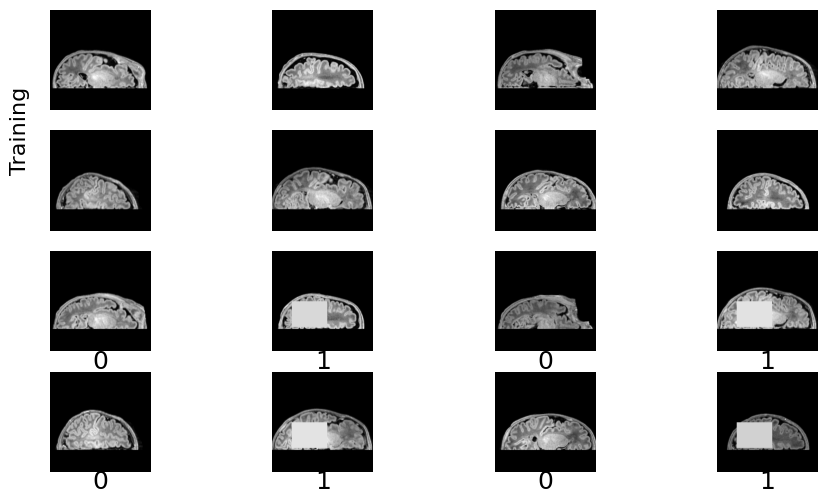

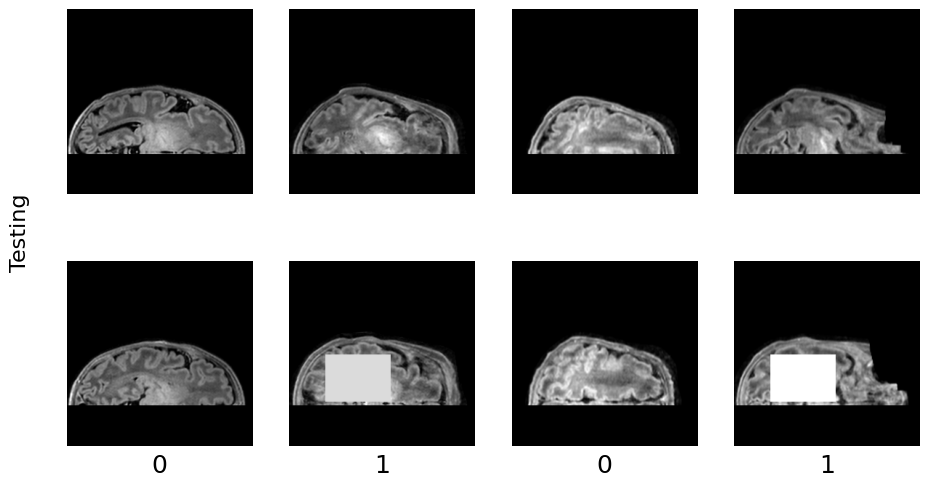

In [16]:
pickle_path = '../siamese/data/pairs_white_90.pkl'
plot_data(pickle_path)

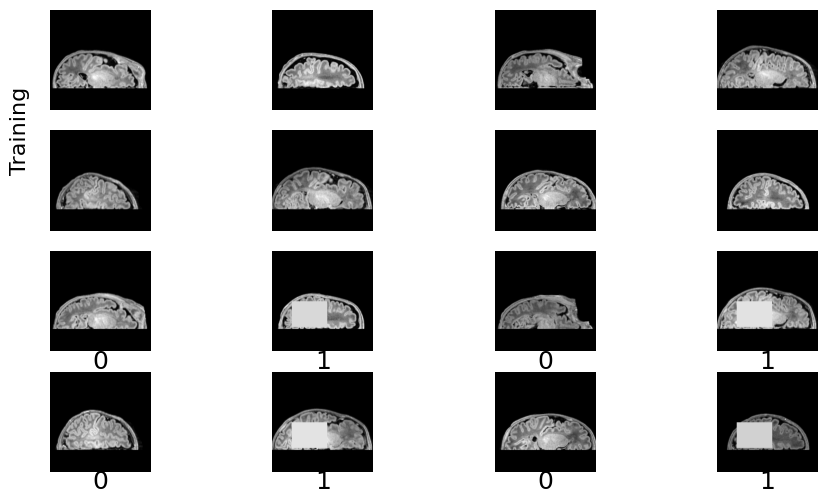

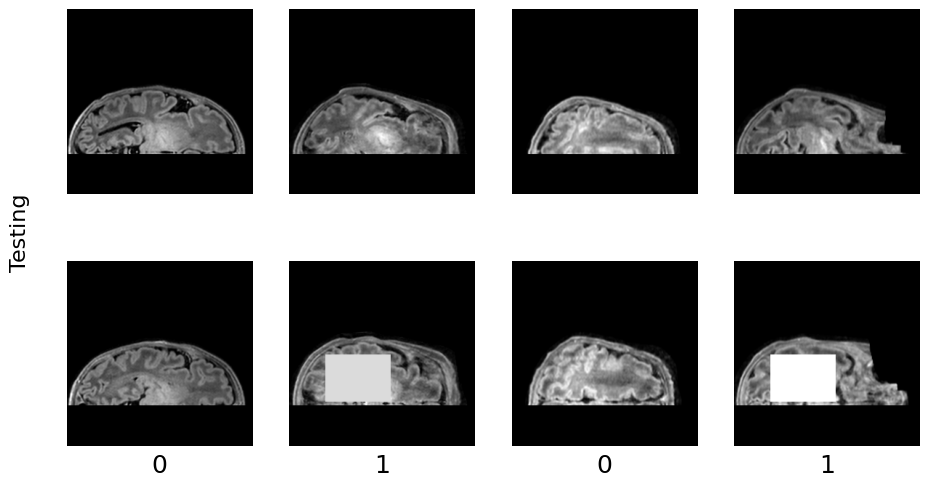

In [17]:
pickl_path = "../siamese/data/pairs_white_small_RGB_90.pkl"
plot_data(pickle_path)

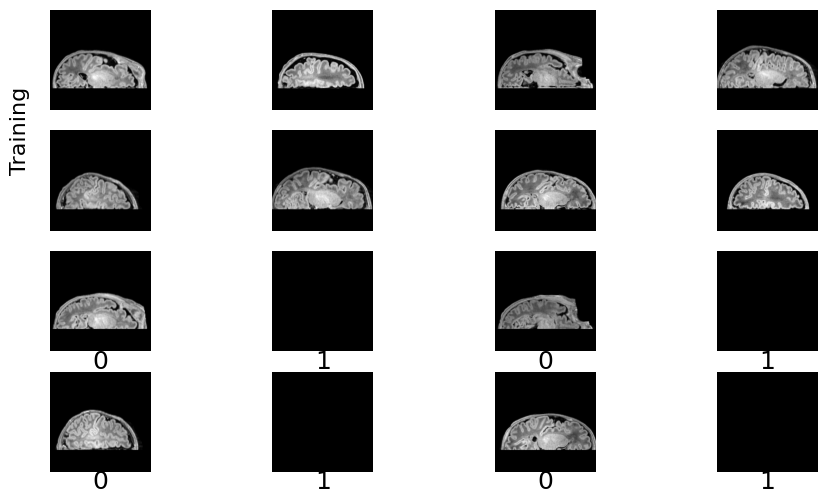

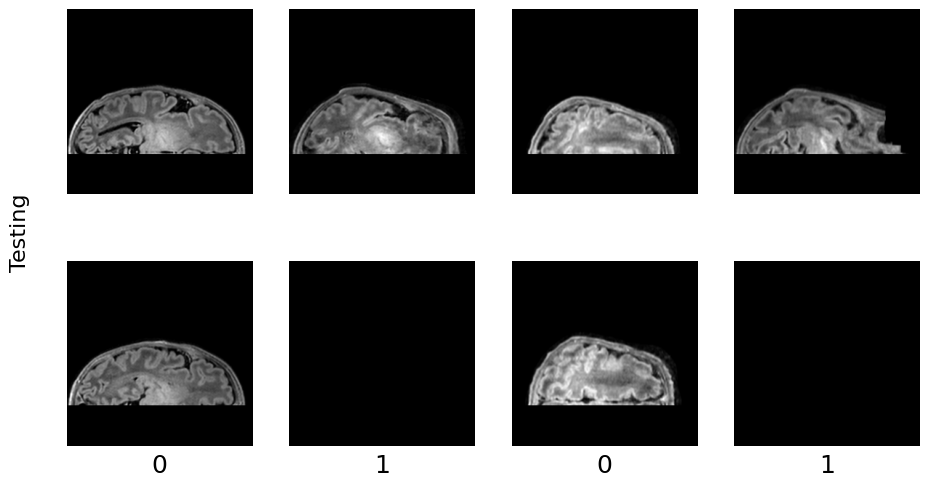

In [18]:
pickle_path = '../siamese/data/pairs_blanks_90.pkl'
plot_data(pickle_path)

In [19]:
sorted(glob("../siamese/data/*.pkl"))

['../siamese/data/pairs_650_650_176.pkl',
 '../siamese/data/pairs_Gray_90_randshape.pkl',
 '../siamese/data/pairs_RGB_90_randshape.pkl',
 '../siamese/data/pairs_blanks_90.pkl',
 '../siamese/data/pairs_blanks_RGB_90.pkl',
 '../siamese/data/pairs_noise3_GRAY_90_T12.pkl',
 '../siamese/data/pairs_noise3_RGB_90_T12.pkl',
 '../siamese/data/pairs_normal_90.pkl',
 '../siamese/data/pairs_normal_RGB_90.pkl',
 '../siamese/data/pairs_normal_RGB_902.pkl',
 '../siamese/data/pairs_normal_RGB_90_T12.pkl',
 '../siamese/data/pairs_white_90.pkl',
 '../siamese/data/pairs_white_RGB_90.pkl',
 '../siamese/data/pairs_white_small_RGB_90.pkl']

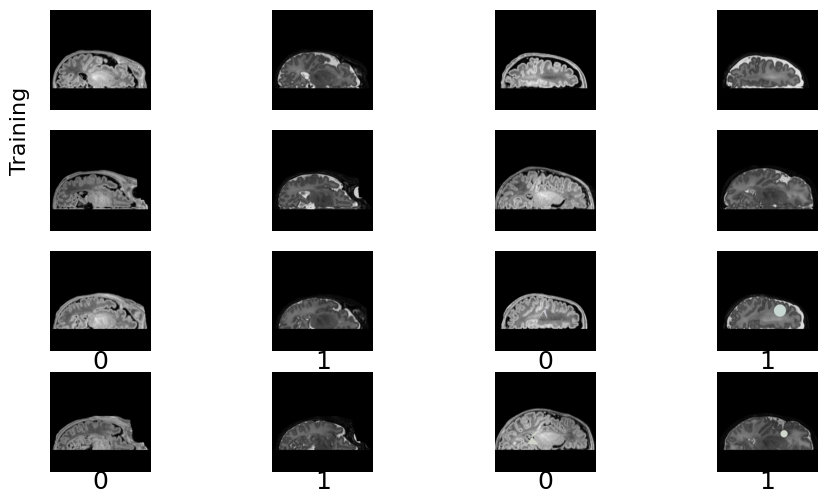

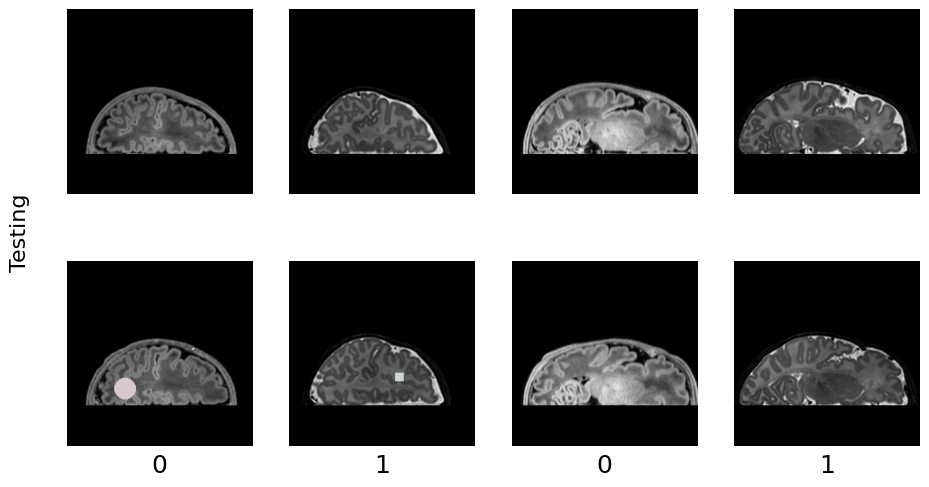

In [20]:
pickle_path = '../siamese/data/pairs_RGB_90_randshape.pkl'
plot_data(pickle_path)

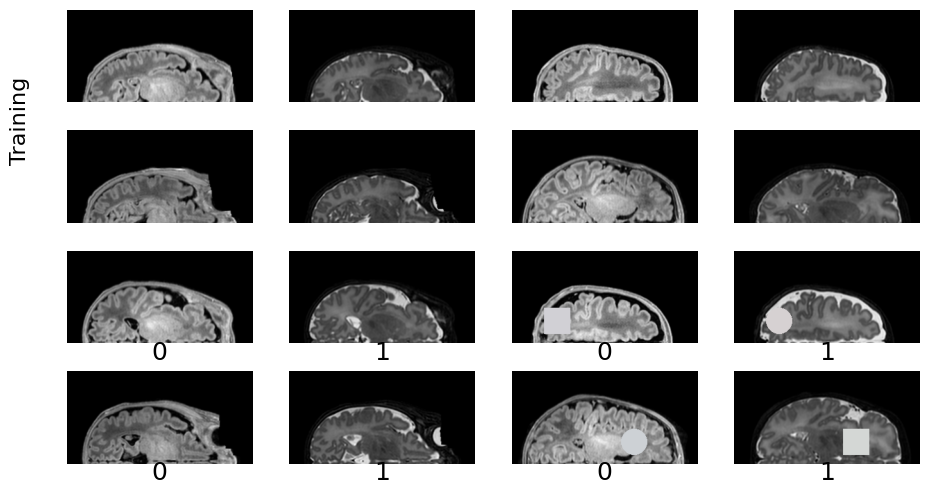

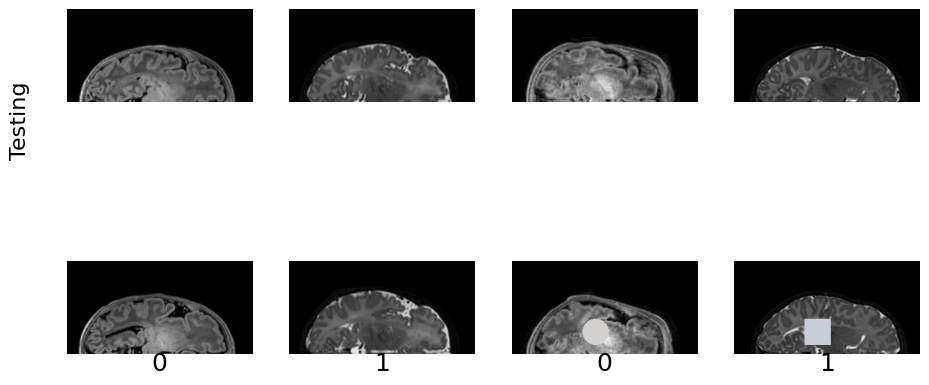

In [21]:
pickle_path = '../siamese/data/pairs_noise3_RGB_90_T12.pkl'
plot_data(pickle_path)

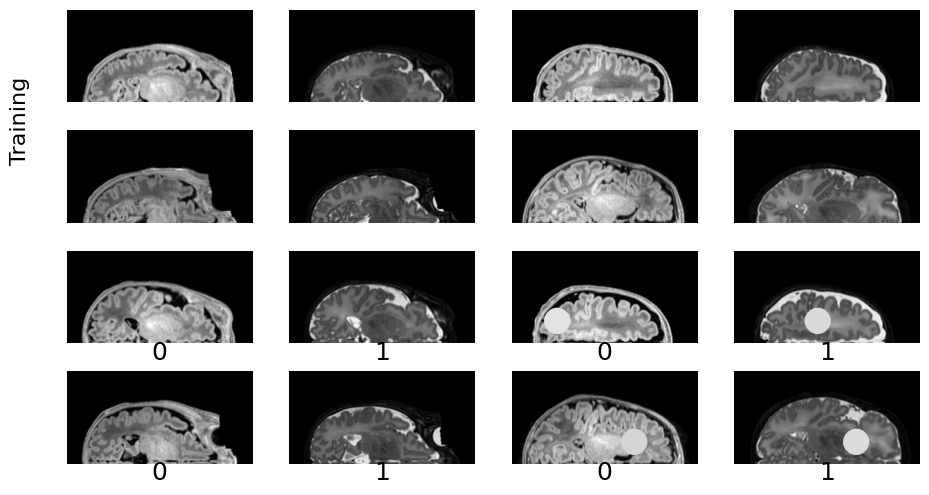

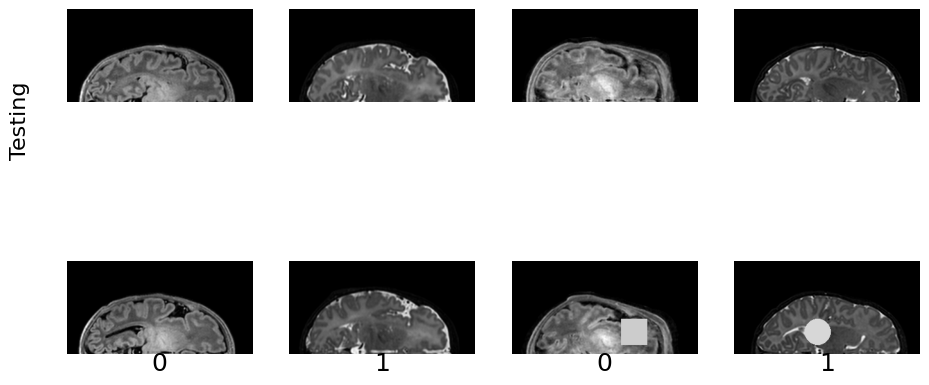

In [22]:
pickle_path = '../siamese/data/pairs_noise3_GRAY_90_T12.pkl'
plot_data(pickle_path)

## Fix dataset functions

In [23]:
from datasets import load_dataset
from PIL import Image
import utils as ut

hf_dataset = load_dataset("agucci/mri-sym2")
import numpy as np

2024-07-05 08:58:00.016792: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-07-05 08:58:00.044385: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-07-05 08:58:00.044408: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-07-05 08:58:00.045179: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-07-05 08:58:00.049938: I tensorflow/core/platform/cpu_feature_guar

In [24]:
from PIL import Image, ImageDraw
import random

In [25]:
def add_noise(image, position='upper', shape='circle', size_range=(10, 30), noise_type='noisy'):
    """
    Add a random noise area to the upper or lower half of the image, close to the middle.
    
    Parameters:
    - image: PIL.Image object.
    - position: 'upper' or 'lower' to specify where the noise should be added.
    - shape: Shape of the noise area ('circle', 'square', or 'polygon').
    - size_range: Tuple indicating the min and max size of the noise area.
    
    Returns:
    - image with added noise area.
    """
    image = image.copy()
    draw = ImageDraw.Draw(image)
    width, height = image.size
    size = random.randint(size_range[0], size_range[1])
    
    # Determine the y-coordinate range based on the position
    if position == 'upper':
        y_center = 3 * height // 8
        y_range = (y_center - size, y_center + size //2)
    elif position == 'lower':
        y_center = 5 * height // 8
        y_range = (y_center - size//2, y_center + size)
    else:
        raise ValueError("Position must be 'upper' or 'lower'.")

    x = random.randint(50, width - 4*size)
    y = random.randint(*y_range)

    shapes = ['circle', 'square']#, 'polygon']
    bboxes = [(50, 90, 90, 130), (110, 90, 150, 130), (170, 90, 210, 130)]
    shape = shapes[random.randint(0, len(shapes) -1 )]
    bbox = bboxes[random.randint(0,2)]

    if noise_type == 'plain':
        fill_color = (255, 255, 255)  # Plain white
    elif noise_type == 'noisy':
        fill_color = tuple(random.randint(200, 215) for _ in range(3))  # Noisy white
    else:
        raise ValueError("Noise type must be 'plain' or 'noisy'.")

    if shape == 'circle':
        draw.ellipse(bbox, fill=fill_color)
        print('circle')
    elif shape == 'square':
        draw.rectangle(bbox, fill=fill_color)
        print('square')

    # bbox = (50, 90, 90, 130)
    # draw.rectangle(bbox, fill=fill_color)
    # bbox = (110, 90, 150, 130)
    # draw.rectangle(bbox, fill=fill_color)
    # bbox = (170, 90, 210, 130)
    # draw.rectangle(bbox, fill=fill_color)
    
    return image

In [26]:

def create_mask_from_edges(edge_points, img_size):
    mask = Image.new('L', img_size, 0)  # Create a black mask
    draw = ImageDraw.Draw(mask)
    draw.polygon(edge_points, outline=255, fill=255)  # Draw the polygon defined by edge points
    return np.array(mask)  # Convert to a NumPy array

def add_noise_within_mask(img, mask, noise_intensity=25):
    img_array = np.array(img)
    # Generate noise
    noise = np.random.normal(loc=0, scale=noise_intensity, size=img_array.shape)
    noisy_img_array = img_array.copy()
    
    # Apply noise only where mask is 255
    mask_expanded = mask[:, :, np.newaxis]  # Expand mask dimensions to match img_array
    noisy_img_array = np.where(mask_expanded == 255, noisy_img_array + noise, noisy_img_array)
    
    return np.clip(noisy_img_array, 0, 255).astype(np.uint8)

def add_white_noise_within_mask(img, mask, noise_intensity_range=(200, 255)):
    img_array = np.array(img)
    # Generate random noise values within the specified range
    noise = np.random.randint(noise_intensity_range[0], noise_intensity_range[1], img_array.shape, dtype=np.uint8)
    noisy_img_array = img_array.copy()
    
    # Apply noise only where mask is 255
    mask_expanded = mask[:, :, np.newaxis]  # Expand mask dimensions to match img_array
    noisy_img_array[mask_expanded == 255] = noise[mask_expanded == 255]
    
    return np.clip(noisy_img_array, 0, 255).astype(np.uint8)

square
square
square
square


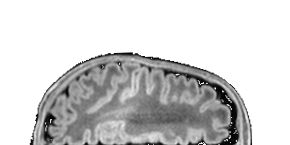

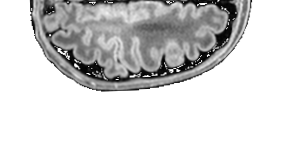

In [29]:
for t1, line1, t2, line2 in zip(hf_dataset['train']['image'][1:], hf_dataset['train']['line'][1:], hf_dataset['test']['image'][1:], hf_dataset['test']['line'][1:]):
    edge_points = ut.non_zeros(t1, plot=False)
    transparent_img = ut.segment2(t1, edge_points)
    rotated_img = ut.rotate(transparent_img, line1, show_line=False)
    slice1, slice2 = ut.slice2(rotated_img)
    slice1_rot = slice1.rotate(180).transpose(Image.FLIP_LEFT_RIGHT)
    noisy = add_noise(slice1_rot)
    noisy2 = add_noise(slice1_rot)
    noisy3 = add_noise(slice1_rot)
    noisy4 = add_noise(slice1_rot)
    # transparent_img, rotated_img, final_img = ut.segment(t1, line1, edge_points, rotate_img=True, show_line=True)
    # half1, half2 = ut.slice_adjusted(segmented)
    # mask = create_mask_from_edges(edge_points, slice1.size)
    # noisy_img_array = add_noise_within_mask(slice1_rot, mask)
    # noisy_img = Image.fromarray(noisy_img_array)
    # noisy_img_array2 = add_white_noise_within_mask(slice1_rot, mask)
    # noisy_img2 = Image.fromarray(noisy_img_array2)

    # display(transparent_img)
    # display(rotated_img)
    display(slice2)
    display(slice1)
    # display(slice1_rot)
    # display(noisy)
    # display(noisy2)
    # display(noisy3)
    # display(noisy4)
    # display(noisy_img)
    # display(noisy_img2)

    break

In [ ]:
img_array = np.array(img.convert('L'))

In [8]:
from PIL import Image

In [10]:
rgba_img.shape
transparent_img = Image.fromarray(rgba_img, 'RGBA')
img_array = np.array(transparent_img)

In [12]:
img_array.shape[:2]

(290, 290)

plot for marketing

In [2]:
im_t1 = []

for t1, line1, t2, line2 in zip(hf_dataset['train']['image'][310:313], hf_dataset['train']['line'][310:313], hf_dataset['test']['image'][310:313], hf_dataset['test']['line'][310:313]):
    # edge_points = ut.non_zeros(t2, plot=False)
    # transparent_img = ut.segment2(t2, edge_points)
    # rotated_img = ut.rotate(transparent_img, line2, show_line=False)
    # slice1, slice2 = ut.slice2(rotated_img)
    # slice1_rot = slice1.rotate(180).transpose(Image.FLIP_LEFT_RIGHT)
    # # noisy = add_noise(slice1_rot)

    # # display(transparent_img)
    # display(rotated_img)
    # display(slice2)
    # # display(slice1)
    # display(slice1_rot)
    # # display(noisy)


    edge_points = ut.non_zeros(t1, plot=False)
    transparent_img = ut.segment2(t1, edge_points)
    line1 = "[{'x': 22.17, 'y': 147.72}, {'x': 246.39, 'y': 148.18}]"
    rotated_img = ut.rotate(transparent_img, line1, show_line=False)
    slice1, slice2 = ut.slice2(rotated_img)
    slice1_rot = slice1.rotate(180)#.transpose(Image.FLIP_LEFT_RIGHT)
    # noisy = add_noise(slice1_rot)
    print(line1)

    # display(transparent_img)
    # display(rotated_img)#rotate(90))
    im_t1.append(rotated_img.rotate(90))
    display(slice2)
    # # display(slice1)
    display(slice1_rot)
    # display(noisy)

NameError: name 'hf_dataset' is not defined

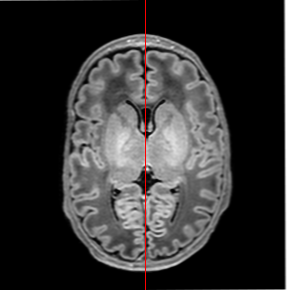

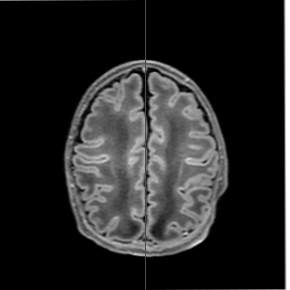

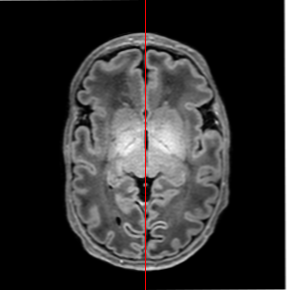

(None, None, None)

In [90]:
display(im_t1[0]), display(im_t1[1]), display(im_t1[2])


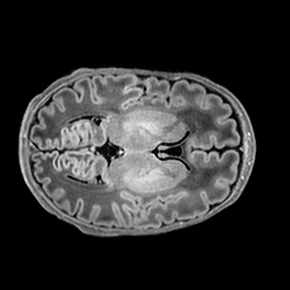

In [51]:
hf_dataset['train'][311]['image']
hf_dataset['train'][312]['image']
hf_dataset['train'][310]['image']

tests

In [ ]:
hf_dataset = load_dataset("agucci/mri-sym2")

t1, line = hf_dataset['train']['image'][0],  hf_dataset['train']['line'][0]
display(t1)
half1, half2 = extract_slices_adj(t1, line)
half1 = (half1.rotate(180).transpose(Image.FLIP_LEFT_RIGHT).convert('L'))
half1

In [ ]:
def add_noise2(image, topleft, bottomright):

    imagecp = image.copy()
    image_np = np.array(imagecp.convert('L'))
    image_np[topleft[0]:topleft[1], bottomright[0]:bottomright[1]] = 0.0

    image_pil = Image.fromarray(image_np, 'L')
    return image_pil

add_noise2(half1, (130, 195), (50, 140))

In [ ]:
add_noise2(half1, (160, 195), (100, 140))

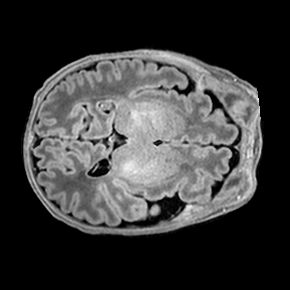

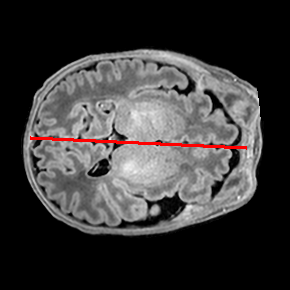

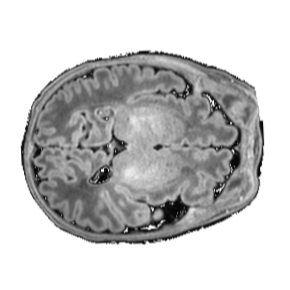

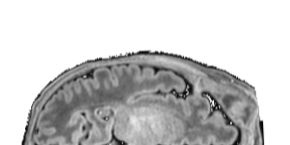

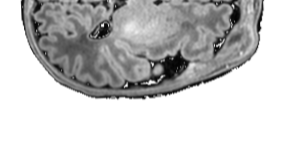

In [15]:
for t1, line1, t2, line2 in zip(hf_dataset['train']['image'][:], hf_dataset['train']['line'][:], hf_dataset['test']['image'][:], hf_dataset['test']['line'][:]):
    edge_points = ut.non_zeros(t1, plot=False)
    transparent_img = ut.segment2(t1, edge_points)
    rotated_img = ut.rotate(transparent_img, line1, show_line=False)
    slice1, slice2 = ut.slice2(rotated_img)
    slice1_rot = slice1.rotate(180).transpose(Image.FLIP_LEFT_RIGHT)

    lined = ut.draw_line(t1, line1)

    display(t1)
    display(lined)
    # display(transparent_img)
    display(rotated_img)
    display(slice2)
    display(slice1)
    # display(slice1_rot)


    break

In [1]:
import utils as ut

2024-09-24 09:55:25.113724: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-09-24 09:55:25.148472: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-09-24 09:55:25.148499: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-09-24 09:55:25.149517: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-09-24 09:55:25.155745: I tensorflow/core/platform/cpu_feature_guar

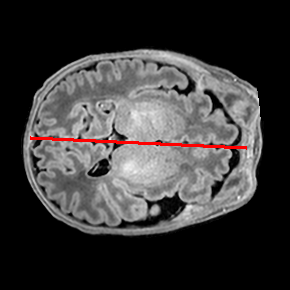

In [4]:
from datasets import load_dataset

hf_dataset = load_dataset("agucci/mri-sym2")

t1 = hf_dataset['train']['image'][0]
line1 = hf_dataset['train']['line'][0]
lined = ut.draw_line(t1, line1)
lined

In [3]:
hf_dataset['train'][0]

{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGBA size=290x290>,
 'line': "[{'x': 30.53, 'y': 137.73} {'x': 246.75, 'y': 147.18}]",
 'rad_score': '2',
 'session': 1100}

In [18]:
dst1 = hf_dataset['train'].map(ut.transforms, batched=True)
dst2 = hf_dataset['test'].map(ut.transforms, batched=True)
dst1[0]

{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGBA size=290x290>,
 'line': "[{'x': 30.53, 'y': 137.73} {'x': 246.75, 'y': 147.18}]",
 'rad_score': '2',
 'session': 1100,
 'slice1': <PIL.PngImagePlugin.PngImageFile image mode=L size=224x224>,
 'slice2': <PIL.PngImagePlugin.PngImageFile image mode=L size=224x224>}

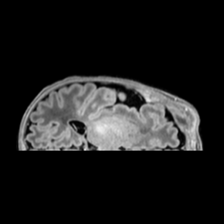

In [22]:
from PIL import Image
dst1[0]['slice1']

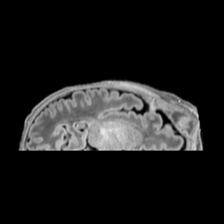

In [24]:
dst1[0]['slice2']

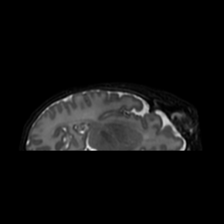

In [19]:
dst2[0]['slice2']

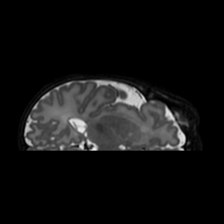

In [23]:
dst2[0]['slice1']